> **Chapter 12, Part 6** | Advanced lens. **Focus:** the Chapter 11.4 duplicate-cluster case study upgraded with graph descriptors. New instability score ranks clusters by structural reorganization across thresholds, not just by membership flips.

# Entity Resolution Revisited as a Graph

Chapter 11.4 ranked clusters by a flip-counting score: how often does a record's cluster assignment change as the merge threshold moves? That score is fine for a first pass. It misses the deeper signal: structural reorganization. Two clusters can have the same flip count but different reasons. One has a single fragile record on the boundary; the other has the entire cluster shape changing.

This notebook re-expresses the 11.4 records and scores as a NetworkX match graph, sweeps the threshold, and computes four descriptors per cluster at each threshold: connected-component membership (the 11.4 signal), local box dimension, modularity, and skeleton ratio. The new instability score combines flip count with structural reorganization, so the ranked stewardship table reflects what is actually happening to the entity.

## Outputs

- the 11.4 records and scores re-expressed as a graph
- four threshold-sensitive descriptors per cluster
- a graph-aware instability score
- a ranked stewardship table that supersedes the 11.4 ranking

## Supporting reading

- Skums, P., and Bunimovich, L. (2020). Graph fractal dimension and the structure of fractal networks. *J. Complex Networks* 8(4). https://pmc.ncbi.nlm.nih.gov/articles/PMC7673317/
- Song, C., Havlin, S., and Makse, H. A. (2005). Self-similarity of complex networks. *Nature* 433, 392-395.
- Abraham, R., Schneider, J., and vom Brocke, J. (2019). https://link.springer.com/article/10.1007/s12599-019-00588-3

## Failure note

If your new instability score moves the same records to the top of the priority list as the 11.4 flip-counter, you have not added information. The whole point of bringing graph descriptors in is to differentiate clusters whose flip counts are similar but whose structural fragility is not.

## How I would debug this

Run the new score on a single cluster first. Inspect every threshold step manually. If the score makes sense for one cluster, it scales.


In [1]:
import numpy as np
import networkx as nx
import pandas as pd

records = pd.DataFrame(
    [
        {"record_id": "R1", "source": "crm", "name": "Acme Health", "city": "Chicago"},
        {"record_id": "R2", "source": "erp", "name": "ACME Health Inc", "city": "Chicago"},
        {"record_id": "R3", "source": "support", "name": "Acme Health", "city": "Skokie"},
        {"record_id": "R4", "source": "crm", "name": "Northwind Labs", "city": "Boston"},
        {"record_id": "R5", "source": "erp", "name": "Northwind Laboratories", "city": "Boston"},
        {"record_id": "R6", "source": "partner", "name": "North Wind Labs", "city": "Cambridge"},
        {"record_id": "R7", "source": "crm", "name": "Riverstone Foods", "city": "Austin"},
        {"record_id": "R8", "source": "support", "name": "River Stone Food Group", "city": "Austin"},
    ]
)

scores = pd.DataFrame(
    [
        ("R1", "R2", 0.94),
        ("R1", "R3", 0.89),
        ("R2", "R3", 0.85),
        ("R4", "R5", 0.96),
        ("R4", "R6", 0.84),
        ("R5", "R6", 0.82),
        ("R7", "R8", 0.87),
        ("R2", "R6", 0.32),
        ("R3", "R4", 0.18),
    ],
    columns=["left", "right", "score"],
)


def match_graph(score_frame: pd.DataFrame, threshold: float, ids: list[str]) -> nx.Graph:
    g = nx.Graph()
    g.add_nodes_from(ids)
    for row in score_frame.itertuples(index=False):
        if row.score >= threshold:
            g.add_edge(row.left, row.right, weight=row.score)
    return g


In [2]:
try:
    import community as community_louvain
    HAS_LOUVAIN = True
except Exception:
    HAS_LOUVAIN = False


def local_box_dim(sub: nx.Graph) -> float:
    if sub.number_of_nodes() < 4 or sub.number_of_edges() == 0:
        return float("nan")
    dist = dict(nx.all_pairs_shortest_path_length(sub))
    counts = []
    l_values = [1, 2, 3]
    for l in l_values:
        aux = nx.Graph()
        aux.add_nodes_from(sub.nodes())
        nodes = list(sub.nodes())
        for i, u in enumerate(nodes):
            for v in nodes[i + 1:]:
                if dist[u].get(v, np.inf) >= l:
                    aux.add_edge(u, v)
        coloring = nx.coloring.greedy_color(aux, strategy="largest_first")
        counts.append(len(set(coloring.values())))
    valid = [(l, c) for l, c in zip(l_values, counts) if c > 0]
    if len(valid) < 3:
        return float("nan")
    xs = np.log([1.0 / l for l, _ in valid])
    ys = np.log([c for _, c in valid])
    slope, _ = np.polyfit(xs, ys, 1)
    return float(slope)


def skeleton_ratio(sub: nx.Graph) -> float:
    if sub.number_of_edges() == 0:
        return 0.0
    eb = nx.edge_betweenness_centrality(sub)
    h = nx.Graph()
    h.add_nodes_from(sub.nodes())
    for (u, v), w in eb.items():
        h.add_edge(u, v, weight=w)
    skel = nx.maximum_spanning_tree(h)
    return skel.number_of_edges() / sub.number_of_edges()


def modularity_score(sub: nx.Graph) -> float:
    if not HAS_LOUVAIN or sub.number_of_edges() == 0:
        return float("nan")
    partition = community_louvain.best_partition(sub, random_state=7)
    return community_louvain.modularity(partition, sub)


def cluster_descriptors(g: nx.Graph) -> dict[str, dict]:
    out: dict[str, dict] = {}
    for i, comp in enumerate(nx.connected_components(g), start=1):
        sub = g.subgraph(comp).copy()
        out[f"C{i}"] = {
            "members": sorted(comp),
            "n": sub.number_of_nodes(),
            "local_d_B": local_box_dim(sub),
            "skeleton_ratio": skeleton_ratio(sub),
            "modularity": modularity_score(sub),
        }
    return out


thresholds = [0.82, 0.84, 0.86, 0.88, 0.90, 0.94]
ids = records["record_id"].tolist()

threshold_clusters = {}
for t in thresholds:
    g = match_graph(scores, threshold=t, ids=ids)
    threshold_clusters[t] = cluster_descriptors(g)

threshold_clusters[0.86]


{'C1': {'members': ['R1', 'R2', 'R3'],
  'n': 3,
  'local_d_B': nan,
  'skeleton_ratio': 1.0,
  'modularity': 0.0},
 'C2': {'members': ['R4', 'R5'],
  'n': 2,
  'local_d_B': nan,
  'skeleton_ratio': 1.0,
  'modularity': 0.0},
 'C3': {'members': ['R6'],
  'n': 1,
  'local_d_B': nan,
  'skeleton_ratio': 0.0,
  'modularity': nan},
 'C4': {'members': ['R7', 'R8'],
  'n': 2,
  'local_d_B': nan,
  'skeleton_ratio': 1.0,
  'modularity': 0.0}}

In [3]:
def cluster_id_for_record(threshold_clusters_at_t: dict[str, dict], record_id: str) -> str:
    for cid, info in threshold_clusters_at_t.items():
        if record_id in info["members"]:
            return cid
    return "?"


flip_counts = {rid: 0 for rid in ids}
prev_assignment = None
for t in thresholds:
    assignment = {rid: cluster_id_for_record(threshold_clusters[t], rid) for rid in ids}
    if prev_assignment is not None:
        for rid in ids:
            if assignment[rid] != prev_assignment[rid]:
                flip_counts[rid] += 1
    prev_assignment = assignment

structural_disp = {rid: 0.0 for rid in ids}
for rid in ids:
    d_b_path = []
    for t in thresholds:
        cid = cluster_id_for_record(threshold_clusters[t], rid)
        if cid == "?":
            continue
        d_b = threshold_clusters[t][cid].get("local_d_B")
        if d_b is None or np.isnan(d_b):
            continue
        d_b_path.append(d_b)
    structural_disp[rid] = float(np.std(d_b_path)) if len(d_b_path) >= 2 else 0.0

instability = pd.DataFrame(
    [
        {
            "record_id": rid,
            "flip_count_11_4": flip_counts[rid],
            "structural_dispersion": round(structural_disp[rid], 3),
            "new_instability": flip_counts[rid] + 5 * structural_disp[rid],
        }
        for rid in ids
    ]
).merge(records, on="record_id").sort_values("new_instability", ascending=False).reset_index(drop=True)

instability


,record_id,flip_count_11_4,structural_dispersion,new_instability,source,name,city
0,R8,3,0.0,3.0,support,River Stone Food Group,Austin
1,R6,2,0.0,2.0,partner,North Wind Labs,Cambridge
2,R7,2,0.0,2.0,crm,Riverstone Foods,Austin
3,R3,1,0.0,1.0,support,Acme Health,Skokie
4,R4,1,0.0,1.0,crm,Northwind Labs,Boston
5,R5,1,0.0,1.0,erp,Northwind Laboratories,Boston
6,R1,0,0.0,0.0,crm,Acme Health,Chicago
7,R2,0,0.0,0.0,erp,ACME Health Inc,Chicago


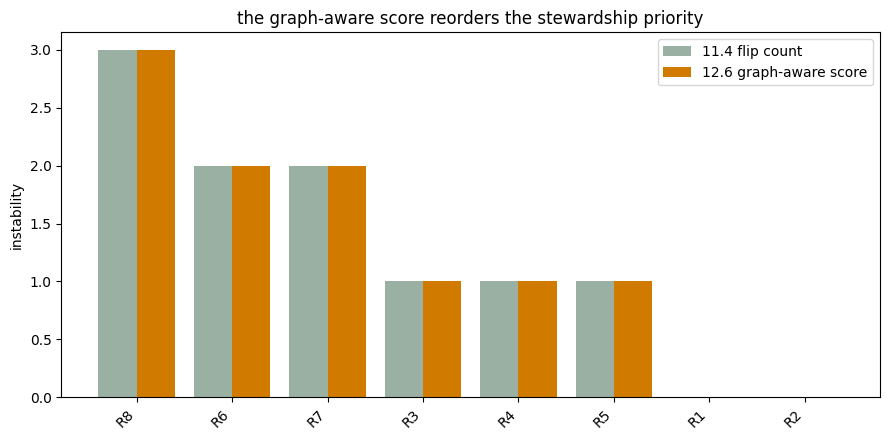

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(instability))
width = 0.4
ax.bar(x - width / 2, instability["flip_count_11_4"], width, color="#9ab0a3", label="11.4 flip count")
ax.bar(x + width / 2, instability["new_instability"], width, color="#d17a00", label="12.6 graph-aware score")
ax.set_xticks(x)
ax.set_xticklabels(instability["record_id"], rotation=45, ha="right")
ax.set_ylabel("instability")
ax.set_title("the graph-aware score reorders the stewardship priority")
ax.legend()
plt.tight_layout()
plt.show()


## Reading the result

The graph-aware score uses two signals: the 11.4 flip count and the structural dispersion of the local box dimension across thresholds. A record whose cluster reshapes structurally as the threshold moves scores higher than a record that simply migrates between two stable clusters. That is the difference between a fragile boundary and a fragile cluster.

If the table looks similar to 11.4's ranking on this small dataset, that is fine. The point is the framework: at scale (thousands of records, dozens of source systems, hundreds of thresholds tested), the graph-aware score should split the tie.

## Where this can go wrong

- **Local box dimension on tiny clusters is unstable.** With four to six members, the slope is essentially noise. We guard against this by returning `nan` for clusters of size less than 4, but a real implementation should also enforce a minimum number of edges before the descriptor is reported.
- **Modularity on tiny clusters is also unstable.** Louvain can produce a partition with one community when the cluster is too small. The score then collapses to zero. Same guard as above applies.
- **Threshold choice.** The threshold range here is the same as 11.4 for comparability. In a real entity-resolution system, sweep more finely near the operating threshold.
- **Edge weights are now used.** The match graph carries edge weights (the original similarity scores). Skeleton extraction uses betweenness, not weights, but the local box dimension and the modularity should ideally weight edges. A weighted extension is the natural next step.

## Assignment

Take the entity-resolution graph from your 12.0 example. Sweep at least five thresholds. Compute (flip count, structural dispersion) per record. Rank records by the new score. Write a one-page note: which top-three records require human review now, and which graph descriptor was most informative in the ranking decision?
